In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 5


In [6]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [7]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

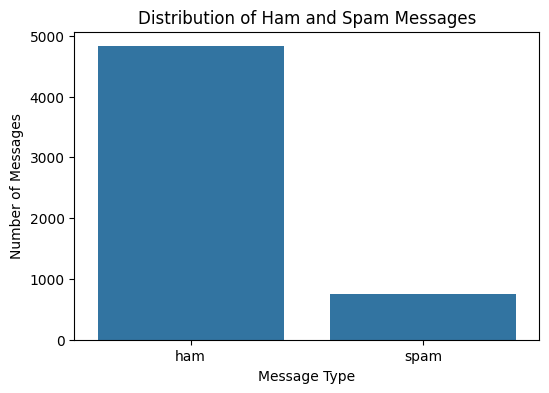

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='label')

plt.title('Distribution of Ham and Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [10]:
label_percentage = df['label'].value_counts(normalize=True) * 100

print(label_percentage)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


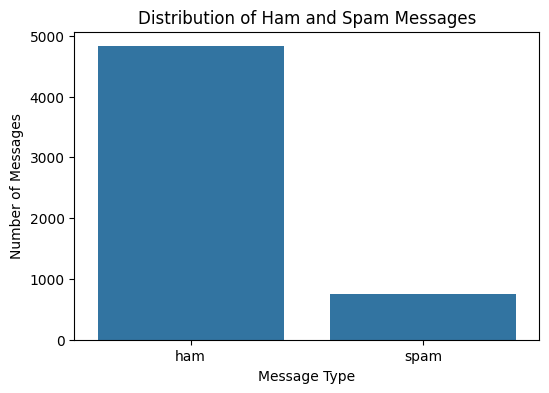

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='label')

plt.title('Distribution of Ham and Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [12]:
label_percentage = df['label'].value_counts(normalize=True) * 100

print(label_percentage)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [13]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [14]:
X = df['message']
y = df['label_num']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5572,)
y shape: (5572,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

In [21]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 7440)
Testing TF-IDF shape: (1115, 7440)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 7440)
Testing TF-IDF shape: (1115, 7440)


In [22]:
from sklearn.naive_bayes import MultinomialNB

In [23]:
model = MultinomialNB()

In [24]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [25]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.968609865470852
Accuracy (%): 96.8609865470852


In [27]:
from sklearn.naive_bayes import MultinomialNB

In [28]:
model = MultinomialNB()

In [29]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [30]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.968609865470852
Accuracy (%): 96.8609865470852


In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 35 114]]


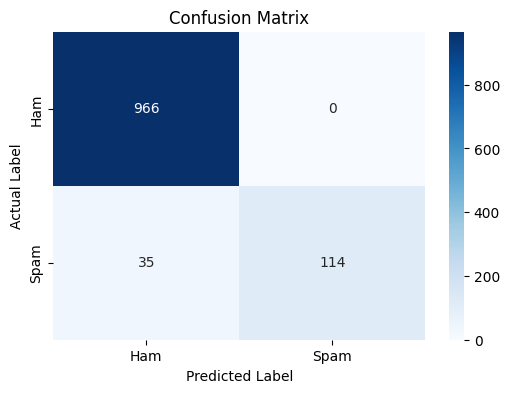

In [34]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 35 114]]


In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [38]:
lr_pred = lr_model.predict(X_test_tfidf)

In [39]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Accuracy (%):", lr_accuracy * 100)

Logistic Regression Accuracy: 0.967713004484305
Logistic Regression Accuracy (%): 96.7713004484305


In [40]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [41]:
lr_cm = confusion_matrix(y_test, lr_pred)

print(lr_cm)

[[966   0]
 [ 36 113]]


In [42]:
def predict_sms(message):
    message_tfidf = tfidf.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [43]:
test_message = "Congratulations! You have won a free prize. Call now!"

print("Message:", test_message)
print("Prediction:", predict_sms(test_message))

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM


In [44]:
test_message = "Hey, are you coming to class today?"

print("Message:", test_message)
print("Prediction:", predict_sms(test_message))

Message: Hey, are you coming to class today?
Prediction: HAM


In [46]:
import joblib

joblib.dump(model, "../models/spam_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
